<a href="https://colab.research.google.com/github/PXrotters/ACS-UPB/blob/main/EP_Plotting_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EP - Data Manipulation & Advanced Plotting (pandas, seaborn & 3D Plotting)

In this lab, we will study data manipulation and visualization using **pandas**, and explore the high level API of **seaborn** for generating visually appealing plots. We will also take a look at 3D plotting using **mplot3d**.

In [2]:
# Some IPython magic
# Put these at the top of every notebook, to get automatic reloading and inline plotting
#%reload_ext autoreload
#%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


Check out these cheetsheets for fast reference to the common libraries:

**Cheat sheets:**
- [python](https://perso.limsi.fr/pointal/_media/python:cours:mementopython3-english.pdf)
- [numpy](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Numpy_Python_Cheat_Sheet.pdf)
- [matplotlib](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Python_Matplotlib_Cheat_Sheet.pdf)
- [sklearn](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Scikit_Learn_Cheat_Sheet_Python.pdf)
- [pandas](https://github.com/pandas-dev/pandas/blob/master/doc/cheatsheet/Pandas_Cheat_Sheet.pdf)

**Other:**
- [Probabilities & Stats Refresher](https://stanford.edu/~shervine/teaching/cs-229/refresher-probabilities-statistics)
- [Algebra](https://stanford.edu/~shervine/teaching/cs-229/refresher-algebra-calculus)

## Pandas Crash Course

Pandas is a high-level data manipulation tool. It is built on the Numpy package and its key data structure is called the DataFrame. DataFrames allow you to store and manipulate tabular data in rows of observations and columns of variables.

Check this official guide for a started in pandas:

[10 minutes to pandas](https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html)

In [3]:

import pandas as pd

Pandas DataFrame is two-dimensional size-mutable, potentially heterogeneous tabular data structure with labeled axes (rows and columns). A Data frame is a two-dimensional data structure, i.e., data is aligned in a tabular fashion in rows and columns. Pandas DataFrame consists of three principal components, the data, rows, and columns.

![](https://media.geeksforgeeks.org/wp-content/uploads/finallpandas.png)



Let's load a publicly available *.csv* dataset into a pandas ***DataFrame***. We will use the popular *iris* dataset.


In [4]:
file_name = "https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv"

df = pd.read_csv(file_name)
df.head(n = 10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


A dataframe's **.describe()** method offers descriptive statistics which include those that summarize the central tendency, dispersion and shape of a dataset’s distribution, excluding NaN values.

In [5]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Let's see some ways in which we can access the DataFrames' data. Each column of a pandas `DataFrame` is a pandas `Series`.

In [6]:
df['petal_width']

,petal_width
0,0.2
1,0.2
2,0.2
3,0.2
4,0.2
...,...
145,2.3
146,1.9
147,2.0
148,2.3


We can do any vectorized operation on a `Series`. Moreover, a pandas `Series` allows us to do conditional selection of rows in a `DataFrame`.

In [7]:
setosas = df[df['species'] == 'setosa']

setosas.head() # only setosa species selected

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


We can add a new column to a pandas `DataFrame`, simply by specifying its name and its contents.

**NB**: the data added to the new column must be the same length as the rest of the `DataFrame`.

In [8]:
df['sepal_area'] = df['sepal_length'] * df['sepal_width'] # adding new columns
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area
0,5.1,3.5,1.4,0.2,setosa,17.85
1,4.9,3.0,1.4,0.2,setosa,14.70
2,4.7,3.2,1.3,0.2,setosa,15.04
3,4.6,3.1,1.5,0.2,setosa,14.26
4,5.0,3.6,1.4,0.2,setosa,18.00


We can work with `Series` as we work with numpy arrays. We perform Min-Max normalization on the `petal_length` column.

In [9]:
# Min-Max Normalization
df['petal_length'] = (df['petal_length'] - df['petal_length'].min()) / (df['petal_length'].max() - df['petal_length'].min())
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area
0,5.1,3.5,0.067797,0.2,setosa,17.85
1,4.9,3.0,0.067797,0.2,setosa,14.70
2,4.7,3.2,0.050847,0.2,setosa,15.04
3,4.6,3.1,0.084746,0.2,setosa,14.26
4,5.0,3.6,0.067797,0.2,setosa,18.00


We can also use the `.apply()` method on either a `Series` or a `DataFrame` to modify its contents, or create a new column.

In [ ]:
def capitalize(col):
  return col.capitalize()

df['species'] = df['species'].apply(capitalize)
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,sepal_area
0,5.1,3.5,0.067797,0.2,Setosa,17.85
1,4.9,3.0,0.067797,0.2,Setosa,14.70
2,4.7,3.2,0.050847,0.2,Setosa,15.04
3,4.6,3.1,0.084746,0.2,Setosa,14.26
4,5.0,3.6,0.067797,0.2,Setosa,18.00


A `DataFrame` also has a `groupby` method, that allows us to work on groupings of rows.

In [10]:
df.groupby('species').mean()

,sepal_length,sepal_width,petal_length,petal_width,sepal_area
species,,,,,
setosa,5.006,3.418,0.078644,0.244,17.2088
versicolor,5.936,2.770,0.552542,1.326,16.5262
virginica,6.588,2.974,0.771525,2.026,19.6846


We can also iterate through each group. A group is another `DataFrame`.

In [11]:
for name, group in df.groupby('species'):
  print("Group:", name)
  print(group.head())
  print("-----")

Group: setosa
   sepal_length  sepal_width  petal_length  petal_width species  sepal_area
0           5.1          3.5      0.067797          0.2  setosa       17.85
1           4.9          3.0      0.067797          0.2  setosa       14.70
2           4.7          3.2      0.050847          0.2  setosa       15.04
3           4.6          3.1      0.084746          0.2  setosa       14.26
4           5.0          3.6      0.067797          0.2  setosa       18.00
-----
Group: versicolor
    sepal_length  sepal_width  petal_length  petal_width     species  \
50           7.0          3.2      0.627119          1.4  versicolor   
51           6.4          3.2      0.593220          1.5  versicolor   
52           6.9          3.1      0.661017          1.5  versicolor   
53           5.5          2.3      0.508475          1.3  versicolor   
54           6.5          2.8      0.610169          1.5  versicolor   

    sepal_area  
50       22.40  
51       20.48  
52       21.39  
53   

### Joins

Pandas allows for joining two or more `DataFrames` together using a common key. We can also do vertical or horizontal concatenation .

![](https://res.cloudinary.com/dyd911kmh/image/upload/f_auto,q_auto:best/v1524477162/data-frames-in-python-banner_cgzjxy.png)

In [12]:
df1 = pd.DataFrame({'A': ['A0', 'A1', 'A2', 'A3'],
                     'B': ['B0', 'B1', 'B2', 'B3'],
                     'C': ['C0', 'C1', 'C2', 'C3'],
                     'D': ['D0', 'D1', 'D2', 'D3']})
df2 = pd.DataFrame({'A': ['A0', 'A1', 'A4', 'A5'],
                     'B': ['B4', 'B5', 'B6', 'B7'],
                     'C': ['C4', 'C5', 'C6', 'C7'],
                     'D': ['D4', 'D5', 'D6', 'D7']})
df3 = pd.DataFrame({'A': ['A8', 'A9', 'A10', 'A11'],
                     'B': ['B8', 'B9', 'B10', 'B11'],
                     'C': ['C8', 'C9', 'C10', 'C11'],
                     'D': ['D8', 'D9', 'D10', 'D11']})

pd.concat([df1, df2, df3]).reset_index(drop = True)

,A,B,C,D
0,A0,B0,C0,D0
1,A1,B1,C1,D1
2,A2,B2,C2,D2
3,A3,B3,C3,D3
4,A0,B4,C4,D4
5,A1,B5,C5,D5
6,A4,B6,C6,D6
7,A5,B7,C7,D7
8,A8,B8,C8,D8
9,A9,B9,C9,D9


In [14]:
pd.merge(df1, df2, on = 'A', how = 'left')

,A,B_x,C_x,D_x,B_y,C_y,D_y
0,A0,B0,C0,D0,B4,C4,D4
1,A1,B1,C1,D1,B5,C5,D5
2,A2,B2,C2,D2,NaN,NaN,NaN
3,A3,B3,C3,D3,NaN,NaN,NaN


## Saving `DataFrames`

Pandas offers a multitude of methods for saving `DataFrames`.

In [15]:
df.to_csv('out.csv', index = False) # saves it locally, check out the files in the right tab of colab

In [16]:
df.to_json()

'{"sepal_length":{"0":5.1,"1":4.9,"2":4.7,"3":4.6,"4":5.0,"5":5.4,"6":4.6,"7":5.0,"8":4.4,"9":4.9,"10":5.4,"11":4.8,"12":4.8,"13":4.3,"14":5.8,"15":5.7,"16":5.4,"17":5.1,"18":5.7,"19":5.1,"20":5.4,"21":5.1,"22":4.6,"23":5.1,"24":4.8,"25":5.0,"26":5.0,"27":5.2,"28":5.2,"29":4.7,"30":4.8,"31":5.4,"32":5.2,"33":5.5,"34":4.9,"35":5.0,"36":5.5,"37":4.9,"38":4.4,"39":5.1,"40":5.0,"41":4.5,"42":4.4,"43":5.0,"44":5.1,"45":4.8,"46":5.1,"47":4.6,"48":5.3,"49":5.0,"50":7.0,"51":6.4,"52":6.9,"53":5.5,"54":6.5,"55":5.7,"56":6.3,"57":4.9,"58":6.6,"59":5.2,"60":5.0,"61":5.9,"62":6.0,"63":6.1,"64":5.6,"65":6.7,"66":5.6,"67":5.8,"68":6.2,"69":5.6,"70":5.9,"71":6.1,"72":6.3,"73":6.1,"74":6.4,"75":6.6,"76":6.8,"77":6.7,"78":6.0,"79":5.7,"80":5.5,"81":5.5,"82":5.8,"83":6.0,"84":5.4,"85":6.0,"86":6.7,"87":6.3,"88":5.6,"89":5.5,"90":5.5,"91":6.1,"92":5.8,"93":5.0,"94":5.6,"95":5.7,"96":5.7,"97":6.2,"98":5.1,"99":5.7,"100":6.3,"101":5.8,"102":7.1,"103":6.3,"104":6.5,"105":7.6,"106":4.9,"107":7.3,"108":6.7,"1

In [17]:
print(df.head().to_markdown())

|    |   sepal_length |   sepal_width |   petal_length |   petal_width | species   |   sepal_area |
|---:|---------------:|--------------:|---------------:|--------------:|:----------|-------------:|
|  0 |            5.1 |           3.5 |      0.0677966 |           0.2 | setosa    |        17.85 |
|  1 |            4.9 |           3   |      0.0677966 |           0.2 | setosa    |        14.7  |
|  2 |            4.7 |           3.2 |      0.0508475 |           0.2 | setosa    |        15.04 |
|  3 |            4.6 |           3.1 |      0.0847458 |           0.2 | setosa    |        14.26 |
|  4 |            5   |           3.6 |      0.0677966 |           0.2 | setosa    |        18    |


In [18]:
print(df.head().to_latex())

\begin{tabular}{lrrrrlr}
\toprule
 & sepal_length & sepal_width & petal_length & petal_width & species & sepal_area \\
\midrule
0 & 5.100000 & 3.500000 & 0.067797 & 0.200000 & setosa & 17.850000 \\
1 & 4.900000 & 3.000000 & 0.067797 & 0.200000 & setosa & 14.700000 \\
2 & 4.700000 & 3.200000 & 0.050847 & 0.200000 & setosa & 15.040000 \\
3 & 4.600000 & 3.100000 & 0.084746 & 0.200000 & setosa & 14.260000 \\
4 & 5.000000 & 3.600000 & 0.067797 & 0.200000 & setosa & 18.000000 \\
\bottomrule
\end{tabular}



In [19]:
print(df.head(n = 3).to_html())

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>sepal_length</th>
      <th>sepal_width</th>
      <th>petal_length</th>
      <th>petal_width</th>
      <th>species</th>
      <th>sepal_area</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>5.1</td>
      <td>3.5</td>
      <td>0.067797</td>
      <td>0.2</td>
      <td>setosa</td>
      <td>17.85</td>
    </tr>
    <tr>
      <th>1</th>
      <td>4.9</td>
      <td>3.0</td>
      <td>0.067797</td>
      <td>0.2</td>
      <td>setosa</td>
      <td>14.70</td>
    </tr>
    <tr>
      <th>2</th>
      <td>4.7</td>
      <td>3.2</td>
      <td>0.050847</td>
      <td>0.2</td>
      <td>setosa</td>
      <td>15.04</td>
    </tr>
  </tbody>
</table>


In [20]:
df.to_sql(name = '<table_name>', con = '<connection>') # insert into a sql database, works with a valid connection
# check out https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_sql.html

ArgumentError: Could not parse SQLAlchemy URL from given URL string

## Pandas Plotting

Pandas offers a convenient API for plotting data directly from a DataFrame. Of course, the plotting API is build upon `matplotlib` as a low level backend. We can use that to manipulate plots as in the previous lab.
Check out the official documentation for visualization:

[Pandas Plotting Docs](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html#visualization)


For a quick reference, check the official cookbook.

[Pandas Plotting Cookbook](https://pandas.pydata.org/pandas-docs/stable/user_guide/cookbook.html#cookbook-plotting)

We will use the high level plotting API to visualize the Iris Dataset.

<Axes: >

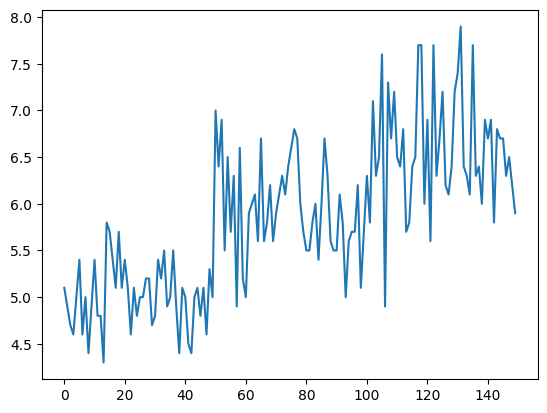

In [21]:
df['sepal_length'].plot()

<Axes: >

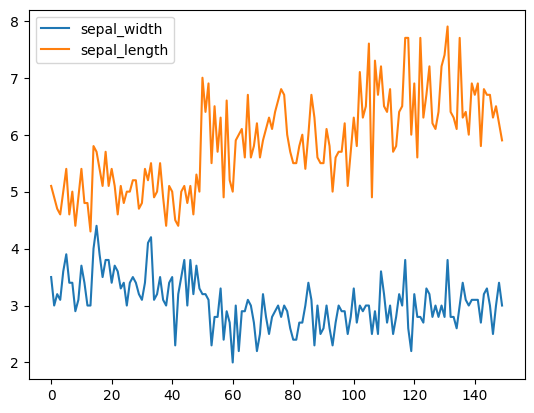

In [22]:
df[['sepal_width', 'sepal_length']].plot()

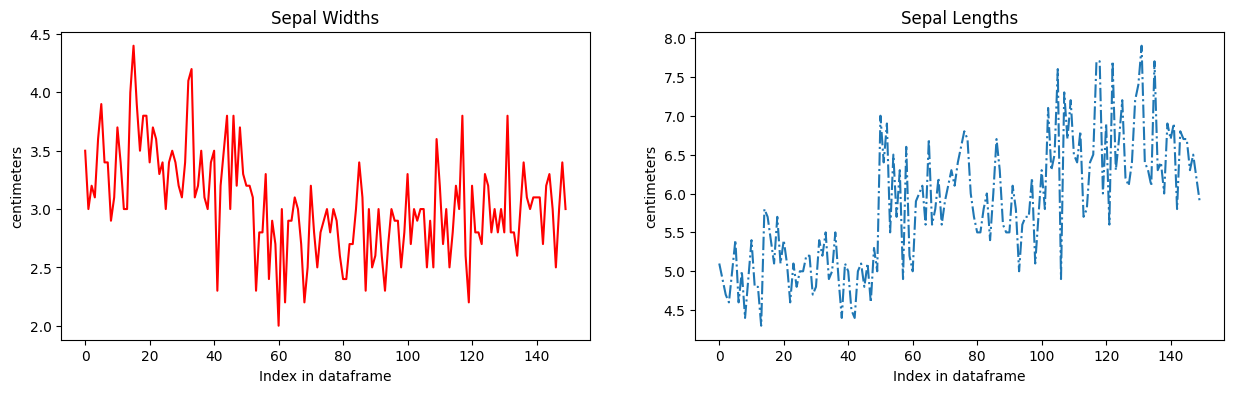

In [23]:
fig, ax = plt.subplots(1, 2)

df['sepal_width'].plot(ax = ax[0], color = 'r')
df['sepal_length'].plot(ax = ax[1], linestyle = '-.')

ax[0].set_title('Sepal Widths')
ax[1].set_title('Sepal Lengths')

ax[0].set_xlabel('Index in dataframe')
ax[1].set_xlabel('Index in dataframe')

ax[0].set_ylabel('centimeters')
ax[1].set_ylabel('centimeters')


fig.set_size_inches(15, 4)

<Axes: ylabel='Frequency'>

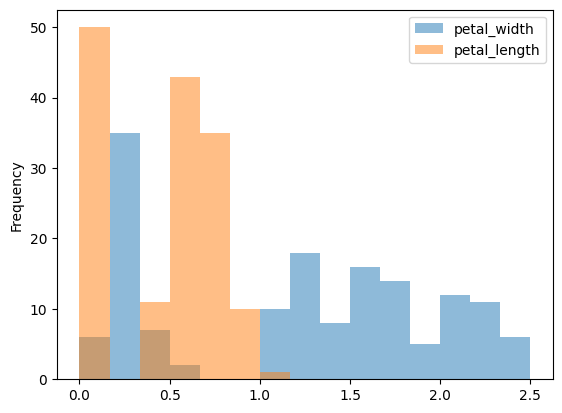

In [24]:
df[['petal_width', 'petal_length']].plot.hist(alpha = 0.5, bins = 15)

<Axes: ylabel='Density'>

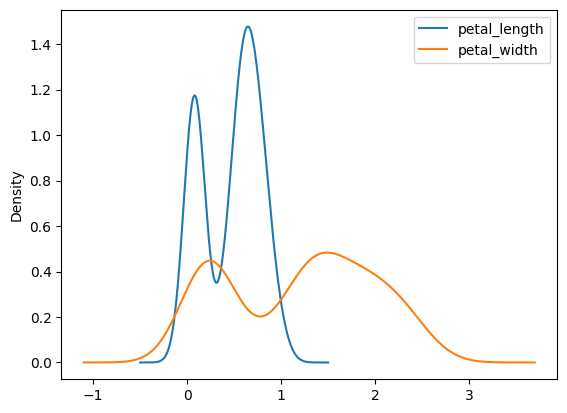

In [25]:
df[['petal_length', 'petal_width']].plot.kde()

## Cool Plots using Seaborn & Pandas


Check out [seaborn](https://seaborn.pydata.org/examples/index.html) for more awesome plots.

In [26]:
import seaborn as sns

sns.set_theme()

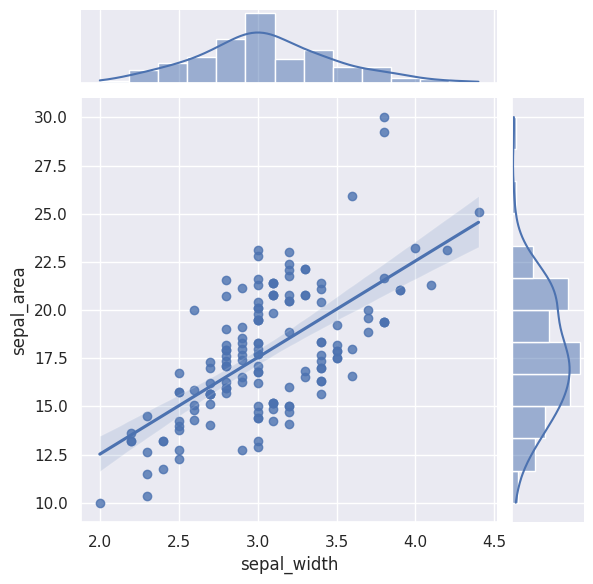

In [27]:
sns.jointplot(x = 'sepal_width', y = 'sepal_area', data = df, kind = 'reg')

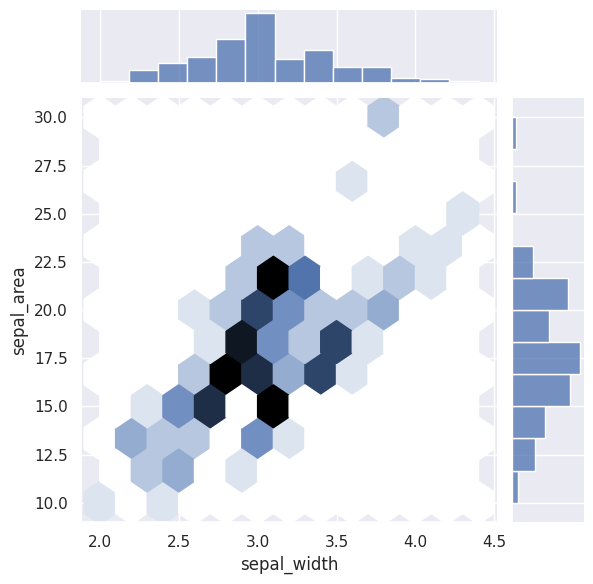

In [28]:
sns.jointplot(x = 'sepal_width', y = 'sepal_area', data = df, kind = 'hex')

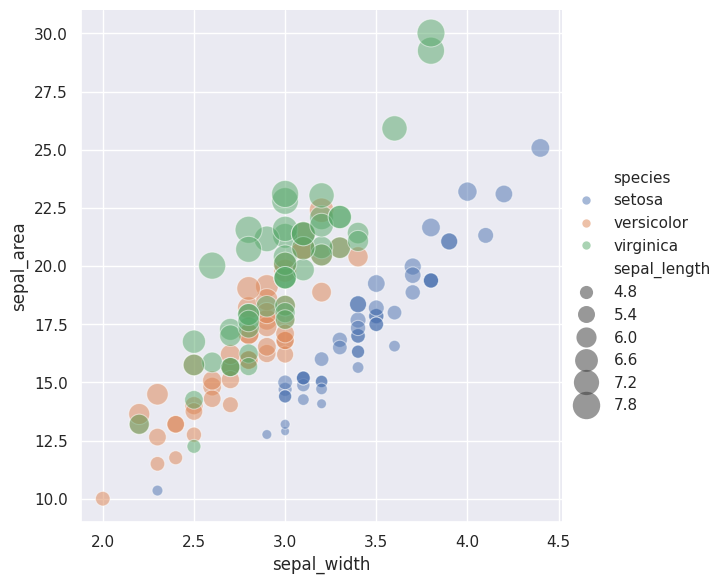

In [29]:
sns.relplot(x="sepal_width", y="sepal_area", hue="species", size="sepal_length", sizes=(40, 400), alpha=.5, height=6, data=df)

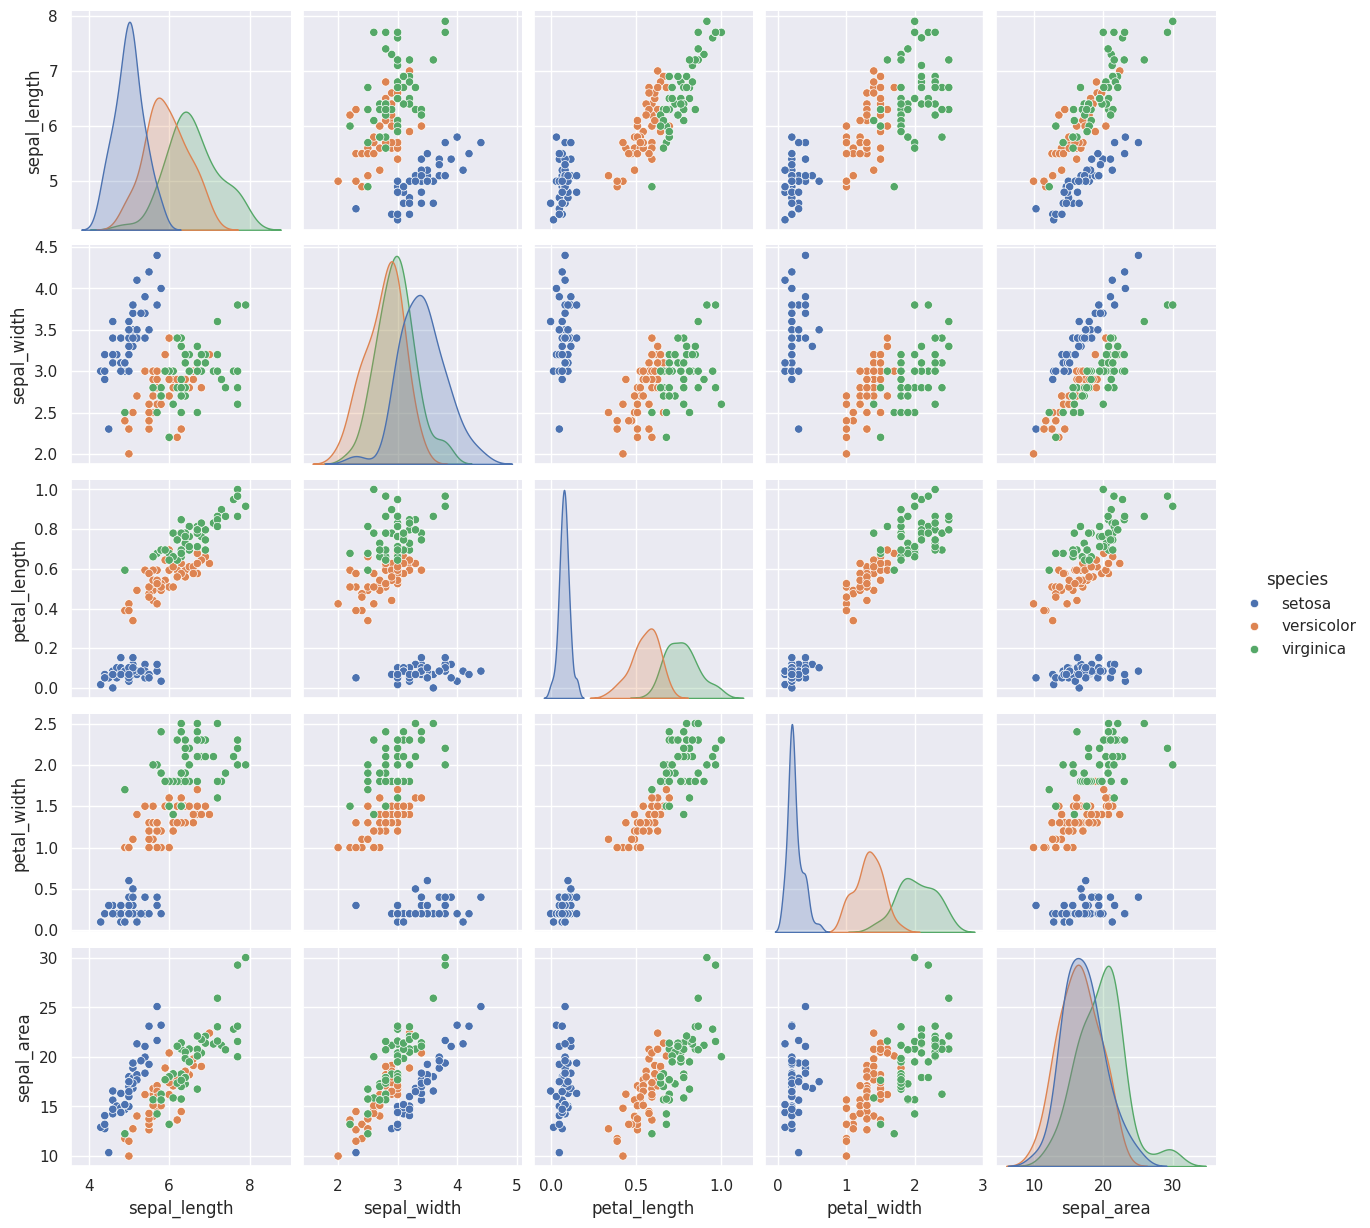

In [30]:
grid = sns.pairplot(df, hue = 'species')

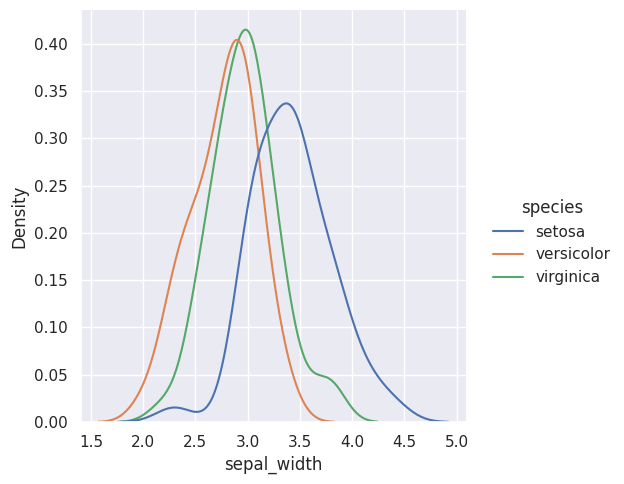

In [31]:
sns.displot(data = df, x = 'sepal_width', kind = 'kde', hue = 'species')

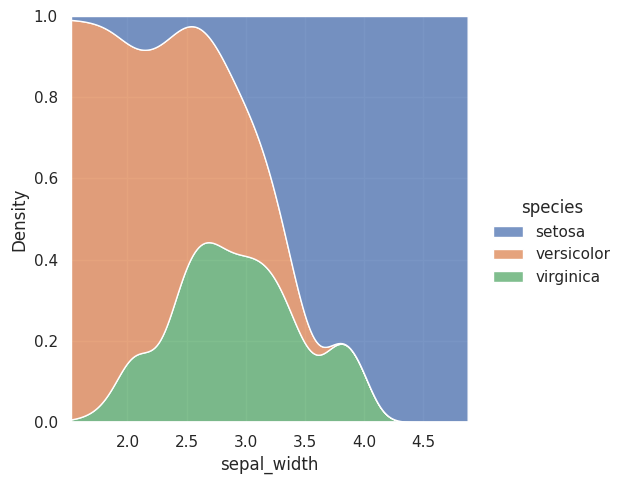

In [32]:
sns.displot(data = df, x = 'sepal_width', kind = 'kde', hue = 'species', multiple = 'fill')

In [33]:
sns.heatmap(df.corr())

ValueError: could not convert string to float: 'setosa'

<Axes: >

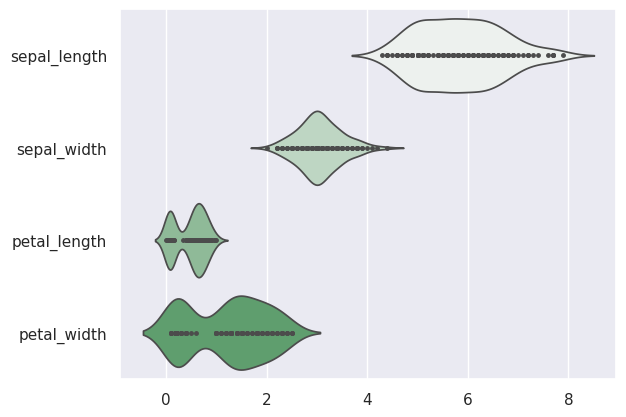

In [34]:
sns.violinplot(data=df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']], palette="light:g", inner="points", orient="h")

## 3D Plotting

In [35]:
from mpl_toolkits.mplot3d import Axes3D


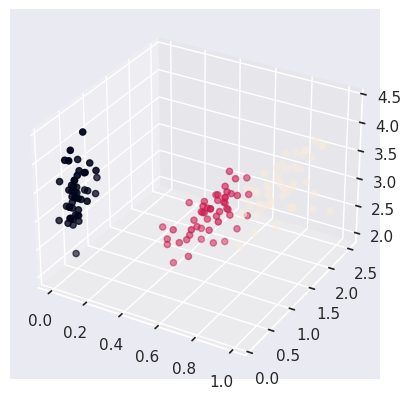

In [36]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['petal_length'], df['petal_width'], df['sepal_width'], zdir='z', s=20, c=df['species'].astype('category').cat.codes, depthshade=True)

# Exercises

After you finish your lab exercises, you should export this notebook as **pdf** and upload it to Moodle. (i.e. **File -> Print**, Destintation: Save as PDF).

In this lab, we will look at COVID data for Romania. The data was retrieved from https://graphs.ro/.

In [37]:
import requests
import json

covid_data = json.loads(requests.get('https://www.graphs.ro/json.php').content)

covid_df = pd.DataFrame(covid_data['covid_romania'])
covid_df.head()

covid_county_data_dfs = []

for i, row in covid_df.iterrows():
  try: # some days have no county information
    county_df = pd.DataFrame(row['county_data'])
  except:
    continue

  county_df['reporting_date'] = row['reporting_date']
  covid_county_data_dfs.append(county_df)


county_df = pd.concat(covid_county_data_dfs)
covid_df = covid_df.drop(['sourceUrl', 'county_data'], axis = 1)

In [38]:
covid_df.head()

,reporting_date,total_cases,new_cases_today,total_tests,new_tests_today,total_deaths,new_deaths_today,OLD_deaths,total_recovered,new_recovered_today,...,tests_upon_request,tests_done_before_today_and_reported_today,rapid_tests,infected_asymptomatic,infected_hospitalized,infected_positive_retests,persons_in_institutional_isolation,persons_in_home_quarantine,persons_in_institutional_quarantine,romania_population_2020
0,2022-11-21,3294446,215,13618262.0,865.0,67253.0,0.0,NaN,NaN,NaN,...,220.0,NaN,5762.0,NaN,650.0,15.0,NaN,NaN,NaN,19317984
1,2022-11-20,3294231,167,13617397.0,1227.0,67253.0,0.0,NaN,NaN,NaN,...,626.0,NaN,3889.0,NaN,628.0,13.0,NaN,NaN,NaN,19317984
2,2022-11-19,3294064,323,13616170.0,1743.0,67253.0,3.0,NaN,NaN,NaN,...,569.0,NaN,7709.0,NaN,613.0,19.0,NaN,NaN,NaN,19317984
3,2022-11-18,3293741,396,13614427.0,1877.0,67250.0,1.0,NaN,NaN,NaN,...,614.0,NaN,9474.0,NaN,619.0,32.0,NaN,NaN,NaN,19317984
4,2022-11-17,3293345,441,13612550.0,2469.0,67249.0,3.0,NaN,NaN,NaN,...,1022.0,NaN,10590.0,NaN,601.0,26.0,NaN,NaN,NaN,19317984


In [39]:
county_df.head()

,county_id,county_name,county_population,total_cases,reporting_date
0,AB,Alba,323778,59583,2022-11-21
1,AR,Arad,415732,78172,2022-11-21
2,AG,Arges,574920,81208,2022-11-21
3,BC,Bacau,580912,69291,2022-11-21
4,BH,Bihor,559992,92159,2022-11-21


# 1. Basic Visualizations

Make 4 subplots. Using pandas as seaborn, plot the number of new cases in a day, the number of recovered patients in day, number of tests in a day, and the number of deaths in day. We are trying to explore the evolution of COVID from the start of the pandemic until today.

**NB:** Make sure to add proper labels, title, axes and legend where necessary.

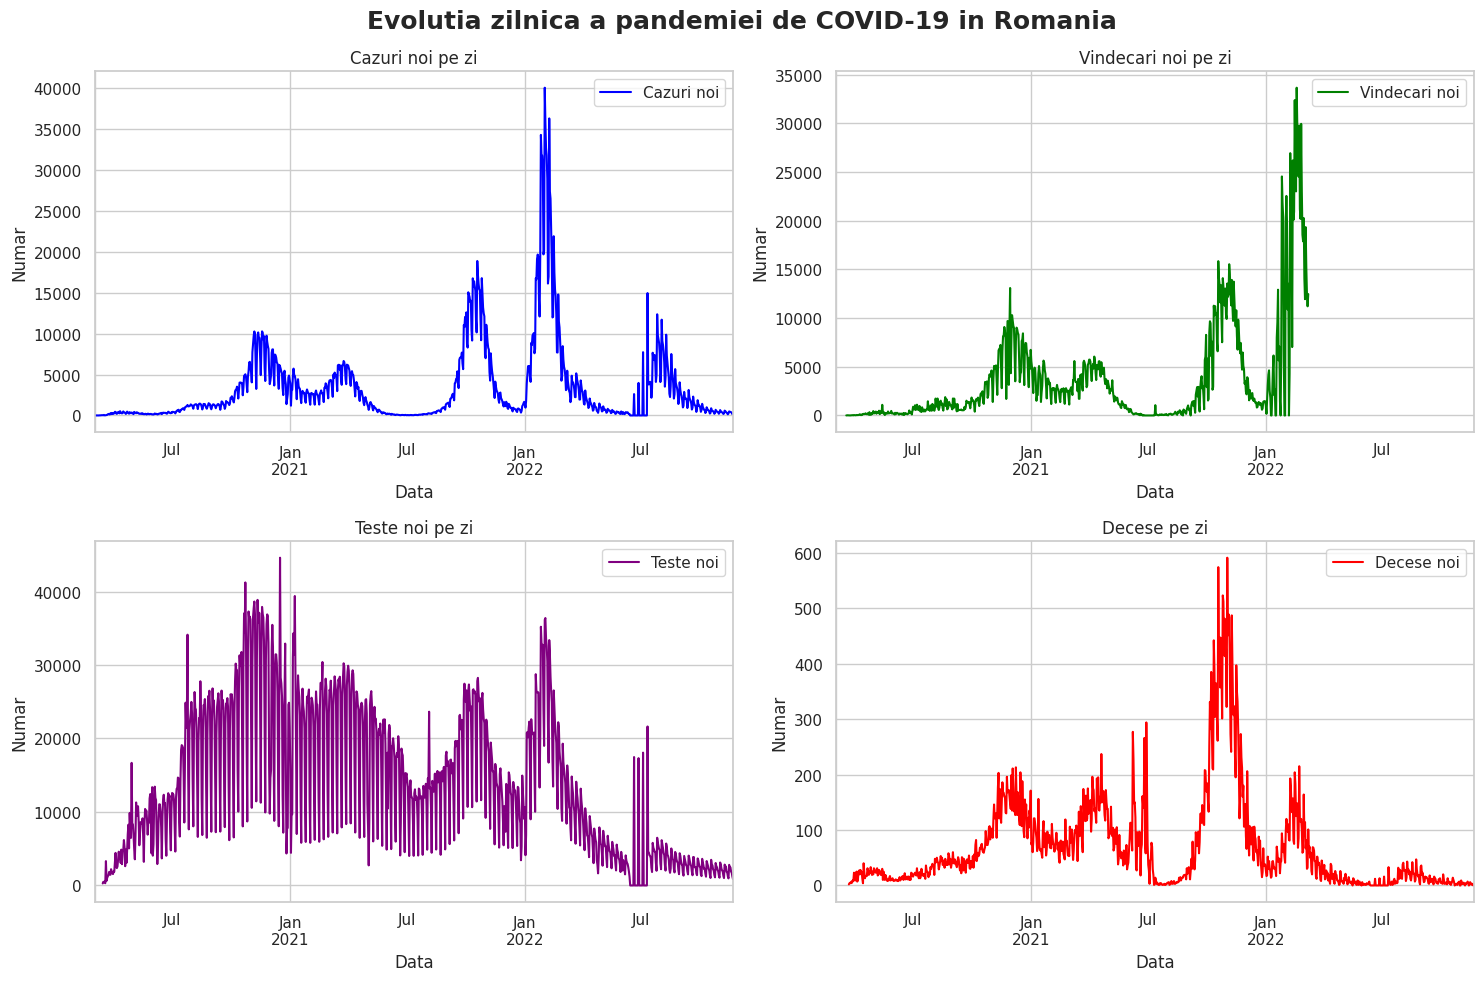

In [62]:
## Pregatirea datelor
# Transformam coloana reporting date in format DateTime pentru a sorta cronologic
covid_df['reporting_date'] = pd.to_datetime(covid_df['reporting_date'])

# Sortam cronologic pentru a avea sens graficul in timp
covid_df = covid_df.sort_values('reporting_date')

sns.set_theme(style="whitegrid")

## Crearea subgraficelor
# Cream o grila de 2 randuri si 2 coloane
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))

# Titlu general pentru toata figura
fig.suptitle('Evolutia zilnica a pandemiei de COVID-19 in Romania', fontsize=18, fontweight='bold')

## Trasarea graficelor

# Cazuri noi
covid_df.plot(x='reporting_date', y='new_cases_today', ax=axes[0, 0], color='blue', label='Cazuri noi')
axes[0, 0].set_title('Cazuri noi pe zi')
axes[0, 0].set_xlabel('Data')
axes[0, 0].set_ylabel('Numar')

# Vindecari
covid_df.plot(x='reporting_date', y='new_recovered_today', ax=axes[0, 1], color='green', label='Vindecari noi')
axes[0, 1].set_title('Vindecari noi pe zi')
axes[0, 1].set_xlabel('Data')
axes[0, 1].set_ylabel('Numar')

# Teste
covid_df.plot(x='reporting_date', y='new_tests_today', ax=axes[1, 0], color='purple', label='Teste noi')
axes[1, 0].set_title('Teste noi pe zi')
axes[1, 0].set_xlabel('Data')
axes[1, 0].set_ylabel('Numar')

# Decese
covid_df.plot(x='reporting_date', y='new_deaths_today', ax=axes[1, 1], color='red', label='Decese noi')
axes[1, 1].set_title('Decese pe zi')
axes[1, 1].set_xlabel('Data')
axes[1, 1].set_ylabel('Numar')

# Evitam suprapunerea textelor
plt.tight_layout()
plt.show()

# 2. Positive testing percentage

Using `pandas`, create a new column that computes the percentage of positive tests in a given day. This new column should be the number of infected people in a day over the number of tests per day.

Plot the evolution of positive tests across time. Compare this to the number of hospitalized patients.

In a different plot, visualize the correlation between positive tests and the number of intensive care patients.

**NB:** Make sure to add proper labels, title, axes and legend where necessary.


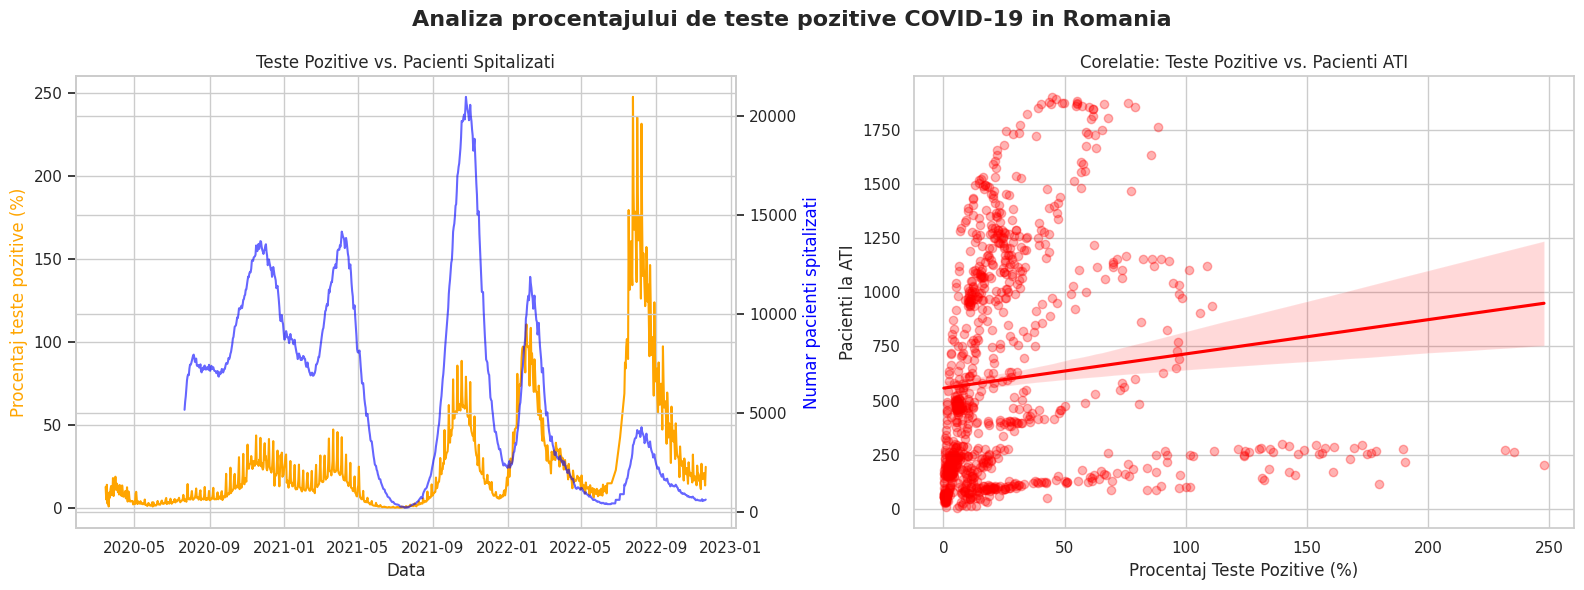

In [68]:
# Cream coloana noua (inmultim cu 100 ca sa obtinem format de procent)
covid_df['positive_test_percentage'] = (covid_df['new_cases_today'] / covid_df['new_tests_today']) * 100

## Vizualizarea datelor

# Cream o grila de 1 rand si 2 coloane (2 grafice alaturate)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.set_theme(style="whitegrid")

# Titlu general pentru toata figura
fig.suptitle('Analiza procentajului de teste pozitive COVID-19 in Romania', fontsize=16, fontweight='bold')

## Trasarea graficelor

# Evolutia in timp
# Procentajul este intre 0-100, iar spitalizatii reprezinta un numar mare, iar daca le punem pe acelasi y, procentajul ar arata ca o linie dreapta in jos
ax1 = axes[0]
ax2 = ax1.twinx() # Cream o clona in partea dreapta a axei y

# Desenam Procentajul pe axa normala (Stanga)
sns.lineplot(data=covid_df, x='reporting_date', y='positive_test_percentage', ax=ax1, color='orange')
# Desenam Spitalizatii pe axa clona (Dreapta)
sns.lineplot(data=covid_df, x='reporting_date', y='infected_hospitalized', ax=ax2, color='blue', alpha=0.6)

# Punem etichete si titluri
ax1.set_title('Teste Pozitive vs. Pacienti Spitalizati')
ax1.set_xlabel('Data')
ax1.set_ylabel('Procentaj teste pozitive (%)', color='orange')
ax2.set_ylabel('Numar pacienti spitalizati', color='blue')

# Corelatia cu ATI
sns.regplot(data=covid_df, x='positive_test_percentage', y='intensive_care_right_now', ax=axes[1], color='red', scatter_kws={'alpha':0.3})

axes[1].set_title('Corelatie: Teste Pozitive vs. Pacienti ATI')
axes[1].set_xlabel('Procentaj Teste Pozitive (%)')
axes[1].set_ylabel('Pacienti la ATI')

# Evitam suprapunerea textelor
plt.tight_layout()
plt.show()


# 3. County Information

Select at least 10 counties of your choosing, and plot the evolution of cases across time.

Plot the number of positive cases on 1000 persons for each of your selected counties. Plot a horizontal line at the 3 / 1000 mark. When the number of positive cases per 1000 persons exceeds 3 / 1000, color your points in a different color from that point onwards.


**NB:** Make sure to add proper labels, title, axes and legend where necessary.


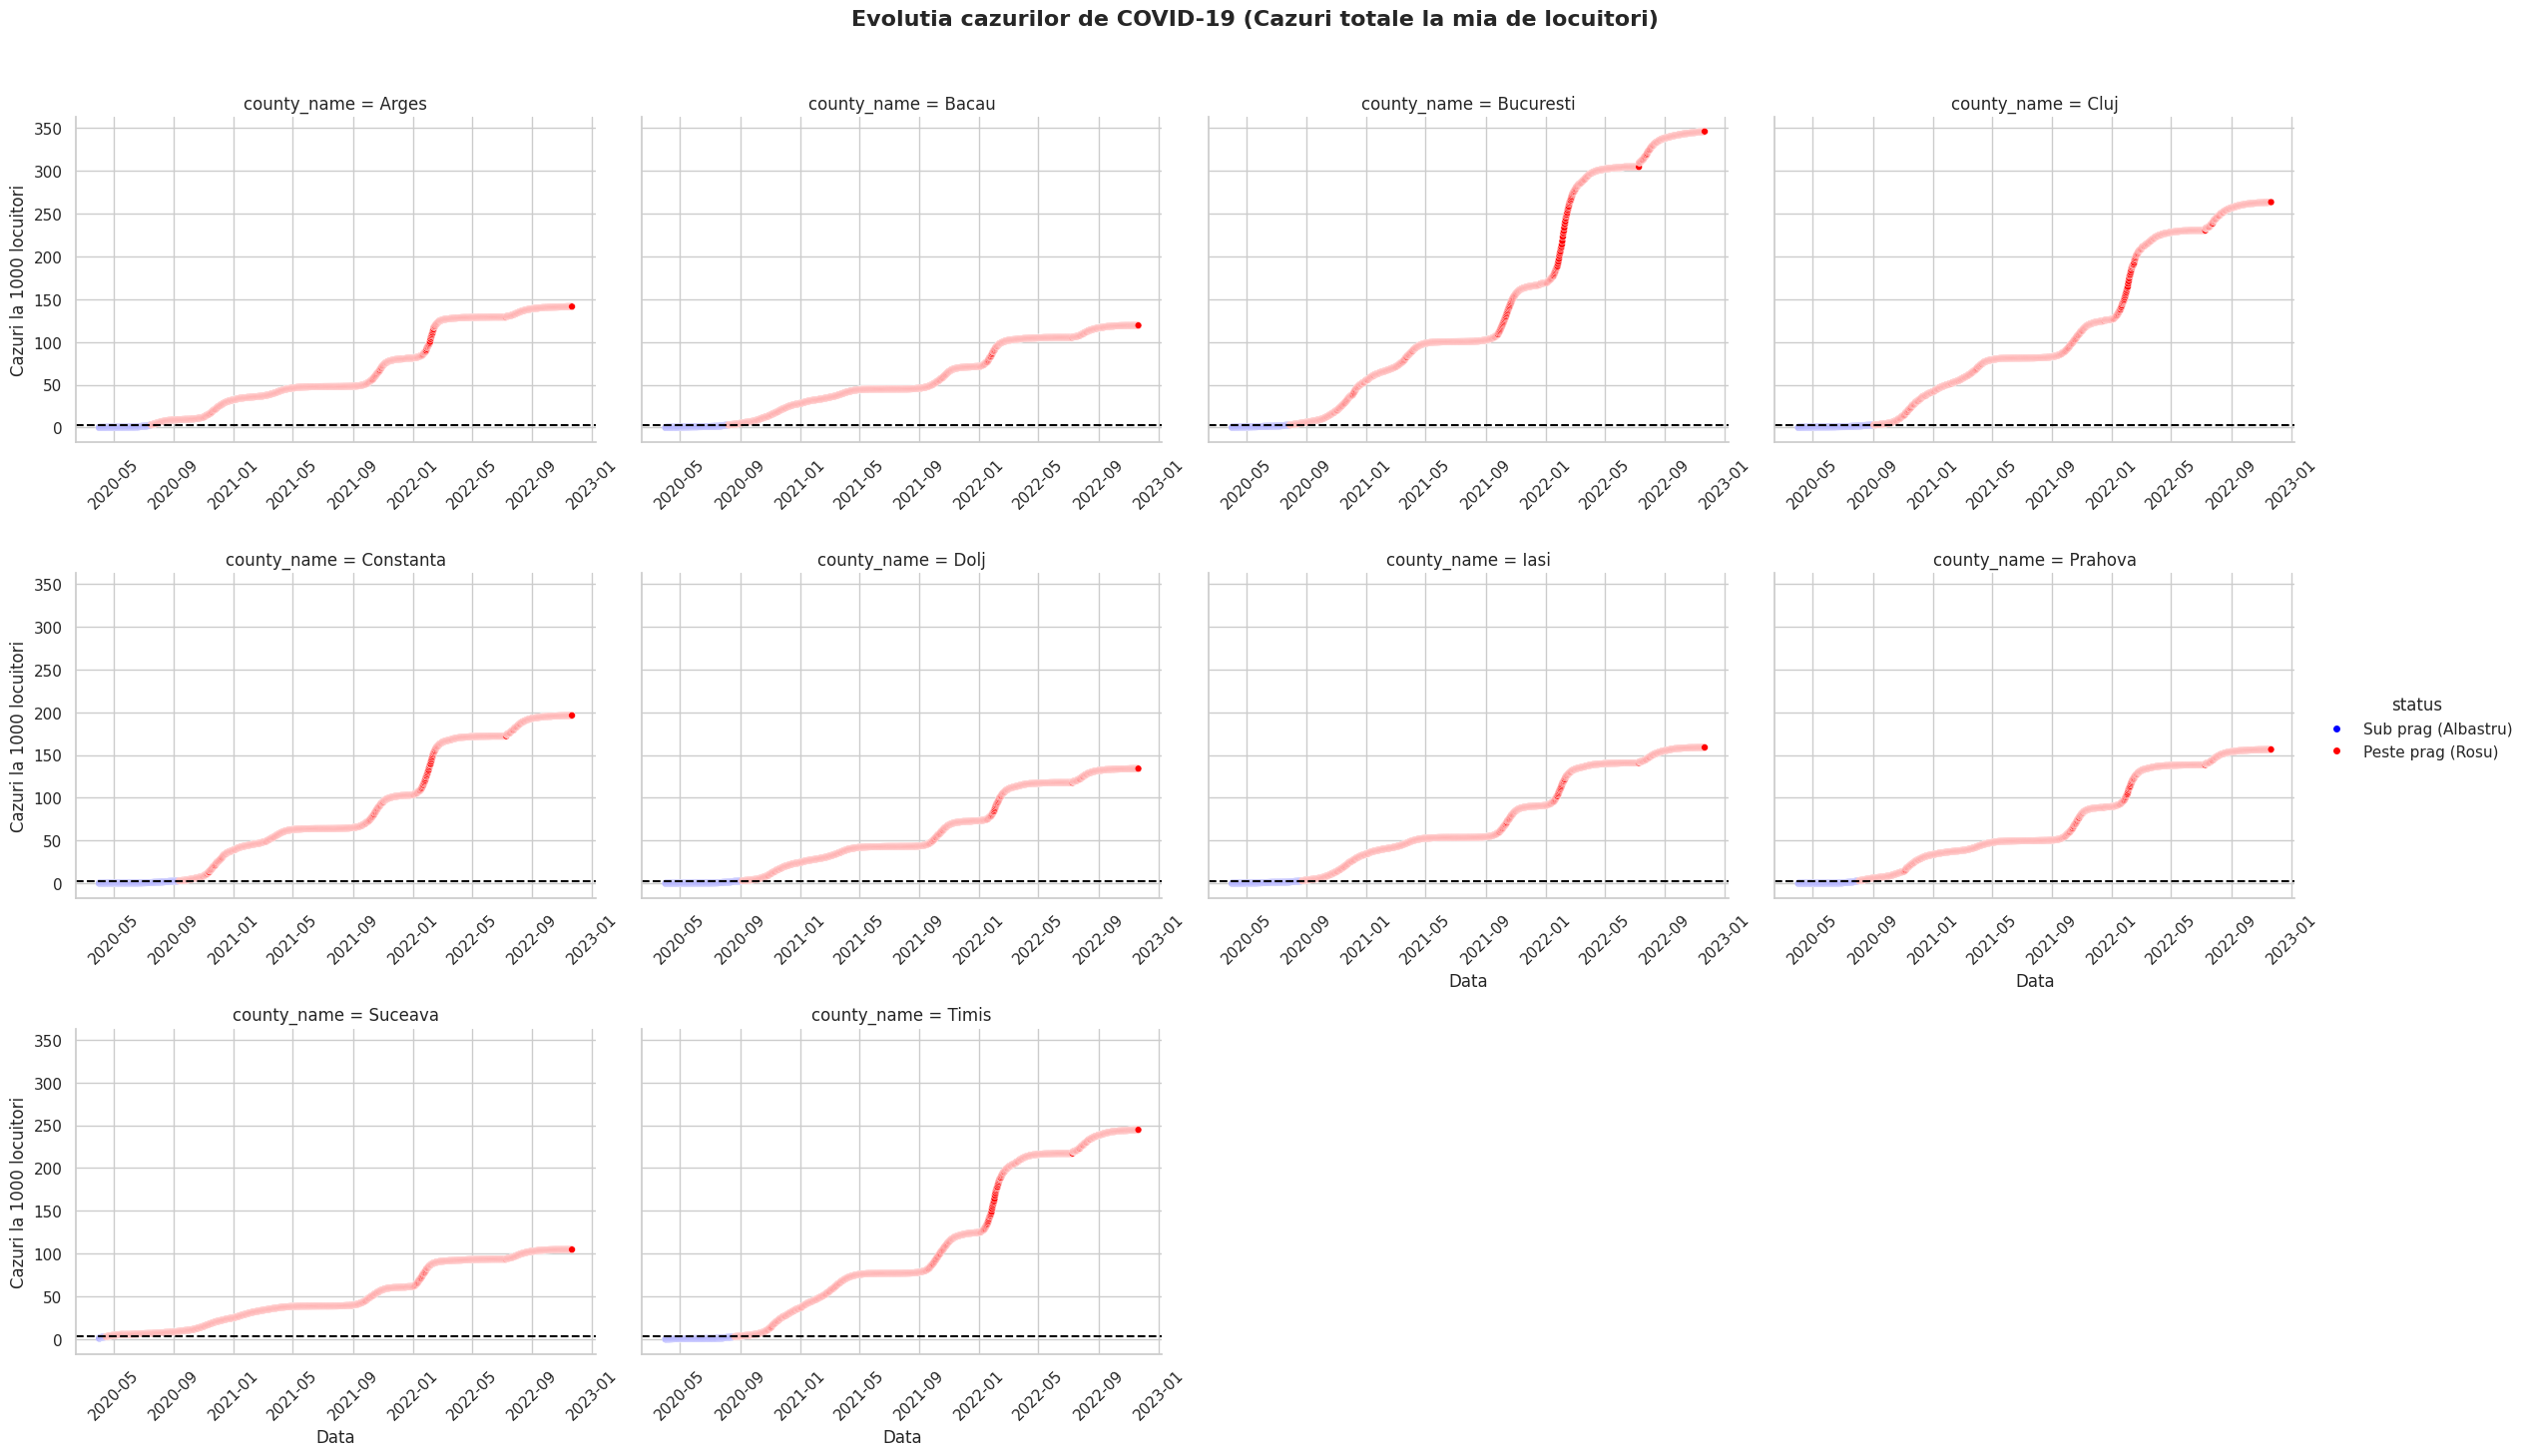

In [85]:
## Pregatirea datelor
# Transformam coloana reporting date in format DateTime pentru a sorta cronologic
county_df['reporting_date'] = pd.to_datetime(county_df['reporting_date'])

# Sortam cronologic pentru a avea sens graficul in timp
county_df = county_df.sort_values(by=['county_name', 'reporting_date'])

# Selectam cele mai mare 10 judete dupa populatie
top_10_counties = county_df.groupby('county_name')['county_population'].max().sort_values(ascending=False).head(10).index.tolist()

# Filtram tabelul ca sa pastram doar aceste 10 judete
df_10 = county_df[county_df['county_name'].isin(top_10_counties)].copy()

# Calculam cazurile cumulate la 1000 de locuitori
df_10['cases_per_1000'] = (df_10['total_cases'] / df_10['county_population']) * 1000

# Cream o coloana noua pentru culoare (regula pragului de 3/1000)
# Daca valoarea > 3 primeste eticheta 'Peste prag', altfel 'Sub prag'
df_10['status'] = ['Peste prag (Rosu)' if x > 3 else 'Sub prag (Albastru)' for x in df_10['cases_per_1000']]


## Trasarea graficelor
sns.set_theme(style="whitegrid")

# sns.relplot creeaza automat subgrafice pentru fiecare judet folosind parametrul col
g = sns.relplot(
    data=df_10,
    x='reporting_date',
    y='cases_per_1000',
    hue='status',                 # Culoarea depinde de coloana status creata mai sus
    col='county_name',            # Creeaza un grafic separat pentru fiecare judet
    col_wrap=4,                   # Pune maxim 5 grafice pe un rand
    palette={'Sub prag (Albastru)': 'blue', 'Peste prag (Rosu)': 'red'}, # Alegem culorile
    kind='scatter',               # Vrem puncte
    s=25,                         # Dimensiunea punctelor
    height=4.5,                     # Inaltimea unui mini-grafic
    aspect=1.3                    # Latimea unui mini-grafic
)

# Adaugam linia orizontala de 3/1000 pe fiecare mini-grafic in parte
for ax in g.axes.flat:
    ax.axhline(y=3, color='black', linestyle='--', linewidth=1.5, label='Pragul de 3/1000')
    ax.set_xlabel('Data')
    ax.set_ylabel('Cazuri la 1000 locuitori')
    ax.tick_params(labelbottom=True) # Afisam parametrii sub fiecare subgrafic
    ax.tick_params(axis='x', rotation=45) # Rotim parametrii de pe ax pentru a nu se suprapune

# Titlu general pentru toata figura
g.fig.suptitle('Evolutia cazurilor de COVID-19 (Cazuri totale la mia de locuitori)', y=1.05, fontsize=16, fontweight='bold')

# Ajustam distanta dintre randurile de subgrafice
g.fig.subplots_adjust(hspace=0.4)
plt.show()

# BONUS

Further expore the dataset, and come up with interesting visualizations of the COVID evolution in Romania.

**Matricea de corelatie**

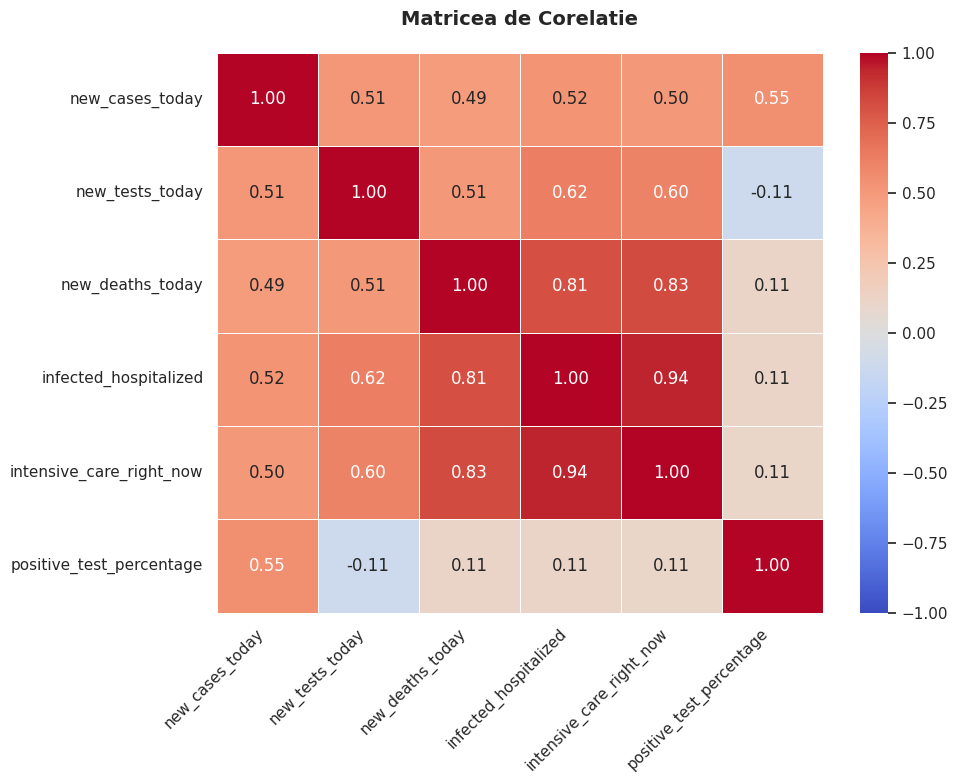

In [86]:
# Alegem doar coloanele numerice cele mai importante
coloane_interes = [
    'new_cases_today',
    'new_tests_today',
    'new_deaths_today',
    'infected_hospitalized',
    'intensive_care_right_now',
    'positive_test_percentage' # Coloana de la ex 2
]

# Calculam matricea de corelatie
matrice_corelatie = covid_df[coloane_interes].corr()

# Cream graficul
plt.figure(figsize=(10, 8))
sns.heatmap(
    matrice_corelatie,
    annot=True,          # Scrie numerele pe patratele
    cmap='coolwarm',     # Culori: rosu pentru corelatie pozitiva, albastru pentru negativa
    vmin=-1, vmax=1,     # Fixam scala de la -1 la 1
    fmt=".2f",           # Arata numerele cu 2 zecimale
    linewidths=0.5
)

plt.title('Matricea de Corelatie', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Rotim textul de jos
plt.tight_layout()
plt.show()

/tmp/ipykernel_518/408360332.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


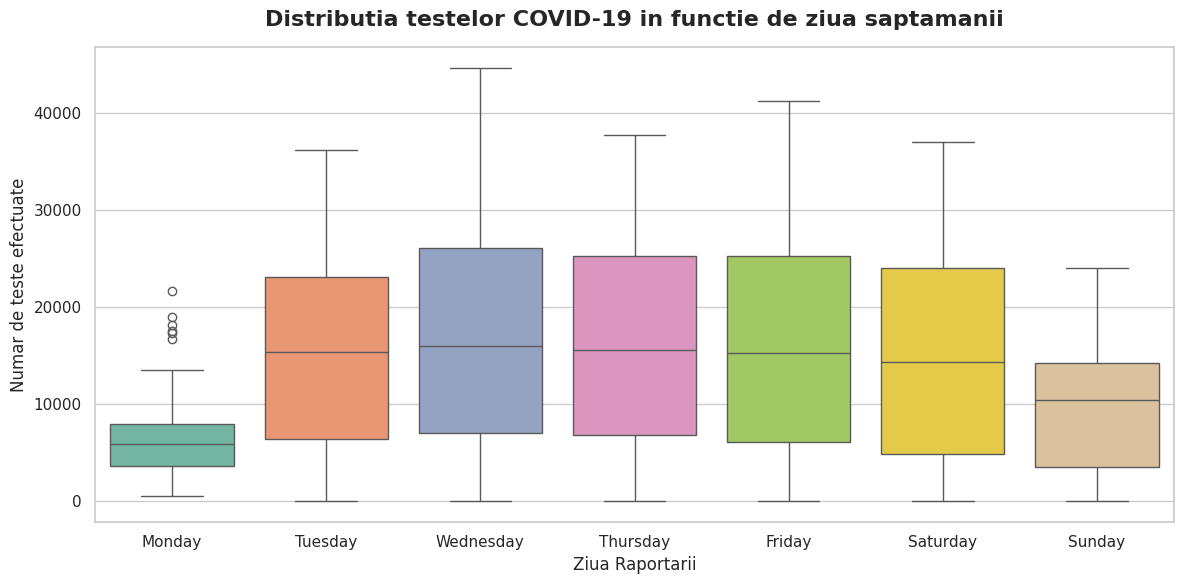

In [89]:
# Extragem ziua din data
covid_df['day_name'] = covid_df['reporting_date'].dt.day_name()

# Definim ordinea corecta a zilelor, altfel Seaborn le va pune alfabetic
zile_ordonate = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Crearea graficului
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Cream un Boxplot -> Order forteaza afisarea cronologica a zilelor
sns.boxplot(
    data=covid_df,
    x='day_name',
    y='new_tests_today',
    order=zile_ordonate,
    palette='Set2'
)

plt.title('Distributia testelor COVID-19 in functie de ziua saptamanii', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Ziua Raportarii', fontsize=12)
plt.ylabel('Numar de teste efectuate', fontsize=12)

# Afisam numarul real
plt.ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()